# CMI and Markov length for ring of toric plaquettes

Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce
import scienceplots

We start from defining ground state density matrix:

\begin{equation}
    \ket{\text{g.s.}} = \prod_i \left( \frac{1+A_i}{\sqrt{2}} \right)\ket{0}^{\otimes N},
\end{equation}

where $A_i$ is the plaquette operator:

\begin{equation}
    A_i = X_{i_1}X_{i_2}X_{i_3}X_{i_4}
\end{equation}

Then, the ground state density matrix is given by:
\begin{equation}
\rho_0 = \left(\prod_i \frac{1+A_i}{\sqrt{2}} \right)\ket{0} \bra{0}^{\otimes N} \left(\prod_i \frac{1+A_i}{\sqrt{2}} \right)
\end{equation}

In [ ]:
# ============================================================
# Defining function computing rho_0
# ============================================================

# -------------------------
# Tensor product helper
# -------------------------
def kron_power(v, N):
    """Compute v ⊗ v ⊗ ... ⊗ v (N times)"""
    return reduce(np.kron, [v] * N)

# -------------------------
# Basis states |0> and |1>
# -------------------------
ket_0 = np.array([1, 0])
ket_1 = np.array([0, 1])

# -------------------------
# Pauli Matrices and Identity
# -------------------------

#Pauli Matrices
Pauli_X= np.array([[0, 1],[1, 0]])
Pauli_Z= np.array([[1, 0],[0, -1]])

# identity matrix 
I = np.eye(2)

# -------------------------
# #Defining local operator
# -------------------------
def local_operator(op, i, N):
    """
    Build operator acting on i-th qubit (0-based index) in N-qubit system.
    """
    ops = [I] * N
    ops[i] = op
    return reduce(np.kron, ops)


# -------------------------
# #Defining plaquette operator
# -------------------------
def plaquette_operator(i1,i2,i3,i4,N):
    """
    A = XXXX
    """
    return local_operator(Pauli_X, i1, N) @ local_operator(Pauli_X, i2, N) @ local_operator(Pauli_X, i3, N) @ local_operator(Pauli_X, i4, N)


# -------------------------
# Functions computing the gound state and rho_0 given the system size and plaquettes' edges
# -------------------------
def ground_state(N, plaquettes):
    ket_0N = kron_power(ket_0, N)
    P = np.eye(2**N)

    for p in plaquettes:
        A = plaquette_operator(*p, N)
        P = ((np.eye(2**N) + A) / np.sqrt(2)) @ P

    return P @ ket_0N

def rho_0_function(N, plaquettes):

    ket_gs = ground_state(N, plaquettes)
    rho_0 = np.outer(ket_gs, ket_gs.conj())
    return rho_0



In [ ]:
# ============================================================
# Computing rho_0 for the system of 4 plaquettes, 12 qubits 
# ============================================================

# -------------------------
# Specifying plaquette edges
# -------------------------
plaquettes_4 = [
        (0, 1, 2, 3),
        (3, 4, 5, 6),
        (6, 7, 8, 9),
        (9, 10, 11, 1),
    ]


# -------------------------
# Computing rho_0
# -------------------------
rho_0 = rho_0_function(12,plaquettes_4)
print(rho_0)
print("Density matrix shape:", rho_0.shape)
print("Number of non-zero entries:", np.count_nonzero(rho_0))

[[0.0625 0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 ...
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]
 [0.     0.     0.     ... 0.     0.     0.    ]]
Density matrix shape: (4096, 4096)
Number of non-zero entries: 256


Subsequantly, we define the noise channel:

\begin{equation}

\mathcal{E}^i_p(\cdot) = (1-p)(\cdot) + pZ_i(\cdot)Z_i

\end{equation}

acting on qubits that are shared between plaquettes. For example, for 12-qubit system with 4 plaquettes, the noise will act on sites $[0,3,6,9]$.

In [ ]:
# ============================================================
# Code to compute density matrix after noise channel application
# ============================================================

# -------------------------
# Defining the phase flip channel
# -------------------------
def phase_flip_channel(rho, p, i, N):
    """ 
    Function implementing the application of the noise channel on qubit i. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho - total density matrix
    """
    Z_i = local_operator(Pauli_Z, i, N)
    return (1 - p) * rho + p * (Z_i @ rho @ Z_i)

# -------------------------
# Repeated application of phase flip chanell -> noise channel
# -------------------------
def noise_channel(rho_0, p, N, indexlist):
    """ 
    Function implementing the noise channel on qubit all qubits. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    indexlist - qubits on which the noise is applied
    p - noise rate 
    N - total system size
    rho_0 - initial density matrix
    """
    rho = rho_0
    for i in indexlist:
        rho = phase_flip_channel(rho, p, i, N)
    return rho 

Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 

In [32]:
# ============================================================
# Code to compute entropies and CMI for given density matrix
# ============================================================

#Calculating von Neumann entropy
def von_neumann_entropy(rho):
    """
    Compute von Neumann entropy S(rho) = -Tr(rho log rho) = -Sum (lamba log lamba), where lambda's are eigenvalues
    """
    eigvals = np.linalg.eigvalsh(rho)

    # remove zeros safely
    eigvals = eigvals[eigvals > 1e-12]

    S = -np.sum(eigvals * np.log2(eigvals))

    return S


#Function to compute reduced density matrix
def partial_trace(rho, keep, N):
    """
    Partial trace over all qubits not listed in keep.

    rho:
        Full density matrix of shape (2^N, 2^N)

    keep:
        List of qubit indices to keep, using Python 0-based indexing.

    N:
        Total number of qubits.

    Returns:
        Reduced density matrix on the qubits in keep.
    """

    keep = sorted(keep)

    # Qubits to trace out
    trace_out = [q for q in range(N) if q not in keep]

    # Reshape rho into tensor form:
    # rho[i1, i2, ..., iN, j1, j2, ..., jN]
    rho_tensor = rho.reshape([2] * N + [2] * N)

    # Trace out qubits from largest index to smallest.
    # This avoids axis-shifting problems after each trace.
    current_N = N

    for q in sorted(trace_out, reverse=True):
        rho_tensor = np.trace(
            rho_tensor,
            axis1=q,
            axis2=q + current_N,
        )
        current_N -= 1

    dim_keep = 2 ** len(keep)

    return rho_tensor.reshape(dim_keep, dim_keep)


#Function to compute CMI depending on noise rate
def CMI(p,indexlist, rho_0, A, B, C, N):
    """
    Compute I(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC).
    """

    rho = noise_channel(rho_0, p, N,indexlist)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N))
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N))
    S_B = von_neumann_entropy(partial_trace(rho, B, N))
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N))

    return S_AB + S_BC - S_B - S_ABC

The first partition into the regions that we are interested in for 12 qubits is given by:

\begin{align}

&A = [1,2]\\

&B = [3,4,5,5,9,10,11,0]\\

&C = [7,8],

\end{align}

where we considered that some edges will be shared between plaquettes and we don't want to trace theut fully

We considered the indexing of qubits staring from 0 to match the Python syntax. Subsequently, we compute CMI for this region partition.

In [37]:
# ============================================================
# Computation of CMI
# ============================================================

# -------------------------
# Defining regions that will be traced out
# -------------------------

A = [1,2]

B = [3,4,5,6,9,10,11,0]

C = [7,8]

# -------------------------
# List of qubits on which we apply the noise
# -------------------------
indexlist_4 = [0,3,6,9]

# -------------------------
# Computing CMI for different noise rates
# -------------------------

#Array of different noise rates
p_array = np.linspace(0.001,0.999,40)

cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],indexlist_4,rho_0,A=A,B=B,C=C,N=12)

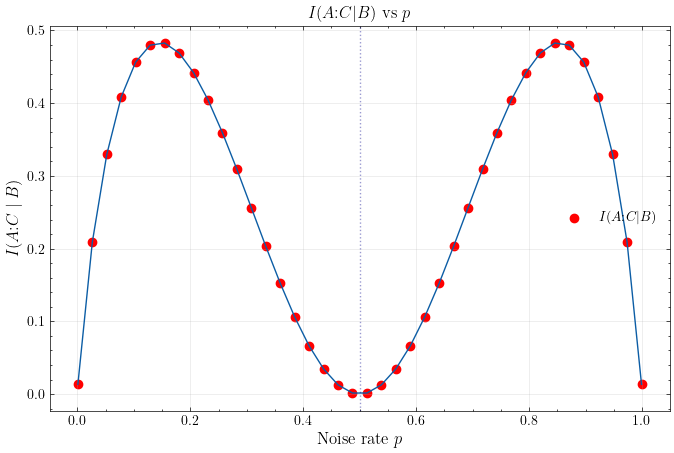

In [40]:
# ============================================================
# Plot of the results of CMI vs noise rate p
# ============================================================


fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use('science')

ax.plot(p_array, cmi_array,lw=1)
ax.scatter(p_array, cmi_array,color='red', label=r'$I(A{:}C|B)$')
ax.axvline(0.5, color='darkblue', ls=':', alpha=0.4)
ax.set_xlabel(r'Noise rate $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C \mid B)$ ', fontsize=12)
ax.set_title(r' $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

The results presented above were computed for 12 qubits, with the partition into regions A,B,C given by: $A = [1,2], B = [3,4,5,6,9,10,11,0],$ and $C = [7,8].$ However, to compute Markov length, we need to repeat the calculation above for different system sizes $r$, where $r$ is the number of plaquettes separating region A from region C. For instance, for the calculation above, $r=1$, because region $B$ encloses region $A$ like a one-dimensional ring. 

Subsequently, we know that CMI should satisfy the following bound with finite Markov length $\xi = \xi(p)$ as long as the system stays in one-phase of matter:
\begin{equation}
I(A:C \mid B)
\leq a e^{-r/\xi(p)} + c_0,
\end{equation}
where $a$ is a proportionality constant (for constatnt size of regions $A$ and $C$) and $c_0$ is a vertical offset, signifying the minimal value to which the CMI function will be converging for incresing system sizes (which is shown in the following plots). In particular, for our system, $c_0 =0$, as observed on the plot above. 

Then, it is possible to compute $\xi = \xi(p)$ considering:
\begin{equation}
\ln(I(A:C \mid B)) = -\frac{1}{\xi(p)} + \ln{a},
\end{equation}
Therfore, for each noise rate $p$, we can compute CMI for differnt system sizes $r$, and then compute $\xi$ by fitting a linear function to the logarithm of CMI (minus offset) versus $r$, and taking the negative inverse of the slope. This computation was executed below.

In [41]:
# -------------------------
# Noise rates used to evaluate Markov length
# -------------------------
p_array2 = np.linspace(0.001,0.999,10)

In [ ]:
# -------------------------
# Function dividing qubit indices into plquette indices
# -------------------------

In [ ]:
# ============================================================
# Defining function computing Markov length
# ============================================================

def fit_markov_length_offset(distances, cmi_values, offset=0.0, threshold=1e-12):
    """
    Fit:

        CMI(r) - offset = a exp(-r / xi)

    so:

        log(CMI(r) - offset) = log(a) - r / xi
    """

    distances = np.array(distances)
    cmi_values = np.array(cmi_values)

    shifted = cmi_values - offset

    # Only keep points where log is well-defined
    mask = shifted > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(shifted[mask])

    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan

    return -1.0 / slope


# ------------------------------------------------------------
# Define distance-dependent partitions
# ------------------------------------------------------------

# Size of regions A and C
LA = 1
LC = 1


# Define maximum distance r
R_max = 3

distances = np.arange(1, R_max + 1)

# ------------------------------------------------------------
# Computing CMI matrix
# ------------------------------------------------------------

cmi_matrix = np.zeros((len(p_array2), len(distances)))

for ip, p in enumerate(p_array2):
    for idd, d in enumerate(distances):

        A_d = list(range(0, LA))
        B_d = list(range(LA, LA + d)) +list( range(LA + d + LC, LA + 2*d + LC))
        C_d = list(range(LA + d, LA + d + LC))
        system_size = len(A_d+B_d+C_d)

        cmi_matrix[ip, idd] = CMI(
            p,
            rho_GHZ_function(system_size),
            A=A_d,
            B=B_d,
            C=C_d,
            N = system_size 
        )


# ============================================================
# Running function computing Markov length for every p
# ============================================================
xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=1.0)
    for ip in range(len(p_array2))
])

In [ ]:
# ------------------------------------------------------------
# Printing output of the computation
# ------------------------------------------------------------

print("xi_array:")
print(xi_array)
print("finite xi values:", np.sum(np.isfinite(xi_array)))